In [3]:
import pandas as pd
Raw_Housing_Data=pd.read_csv("1. Regression - Module - (Housing Prices).csv")


In [4]:
Raw_Housing_Data['Sale Price'].head(10)

0     221900.0
1     538000.0
2     180000.0
3     604000.0
4     510000.0
5    1230000.0
6     257500.0
7     291850.0
8     229500.0
9     323000.0
Name: Sale Price, dtype: float64

In [5]:
Raw_Housing_Data['Sale Price'].tail(10)

21603     507250.0
21604     429000.0
21605     610685.0
21606    1010000.0
21607     475000.0
21608     360000.0
21609     400000.0
21610     402101.0
21611     400000.0
21612     325000.0
Name: Sale Price, dtype: float64

In [6]:
Raw_Housing_Data['Sale Price']

0        221900.0
1        538000.0
2        180000.0
3        604000.0
4        510000.0
           ...   
21608    360000.0
21609    400000.0
21610    402101.0
21611    400000.0
21612    325000.0
Name: Sale Price, Length: 21613, dtype: float64

In [7]:
Raw_Housing_Data['Sale Price'].describe()

count    2.160900e+04
mean     5.401984e+05
std      3.673890e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: Sale Price, dtype: float64

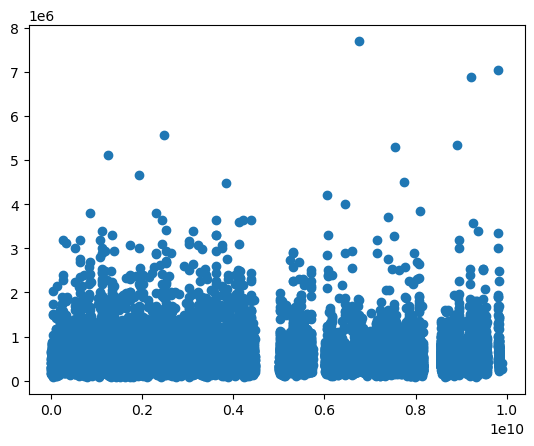

In [8]:
import matplotlib.pyplot as plt
plt.scatter(x = Raw_Housing_Data['ID'], y = Raw_Housing_Data['Sale Price'])

<Axes: xlabel='Sale Price'>

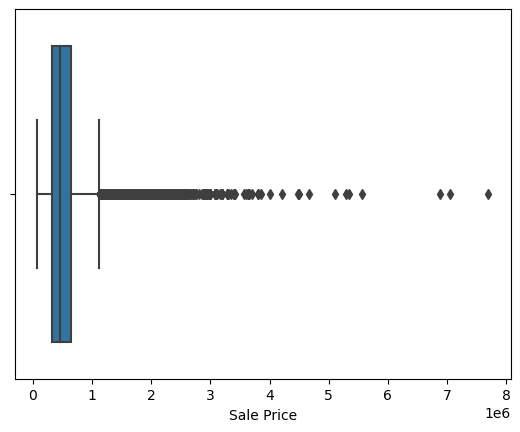

In [9]:
import seaborn as sns
sns.boxplot( x = Raw_Housing_Data['Sale Price'])

In [11]:
q1=Raw_Housing_Data['Sale Price'].quantile(0.25)
q3=Raw_Housing_Data['Sale Price'].quantile(0.75)
iqr=q3-q1

In [12]:
iqr

323050.0

In [13]:
lower_limit=q1-1.5*iqr
upper_limit=q3-1.5*iqr
lower_limit,upper_limit

(-162625.0, 160425.0)

In [16]:
def limit_inputer(value):
    if value>upper_limit:
        return upper_limit
    if value<lower_limit:
        return lower_limit
    else:
        return value

In [17]:
Raw_Housing_Data['Sale Price'] = Raw_Housing_Data['Sale Price'].apply(limit_inputer)

In [18]:
Raw_Housing_Data['Sale Price'].describe()  # Their is change in the all the values as we treated the outlier as variable 

count     21609.000000
mean     160096.086168
std        3810.990308
min       75000.000000
25%      160425.000000
50%      160425.000000
75%      160425.000000
max      160425.000000
Name: Sale Price, dtype: float64

In [19]:
Raw_Housing_Data.dropna(inplace = True, axis = 0, subset = ['Sale Price'])

In [20]:
Raw_Housing_Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21609 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21609 non-null  int64  
 1   Date House was Sold                        21609 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21609 non-null  int64  
 4   No of Bathrooms                            21605 non-null  float64
 5   Flat Area (in Sqft)                        21600 non-null  float64
 6   Lot Area (in Sqft)                         21600 non-null  float64
 7   No of Floors                               21609 non-null  float64
 8   Waterfront View                            21609 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House     

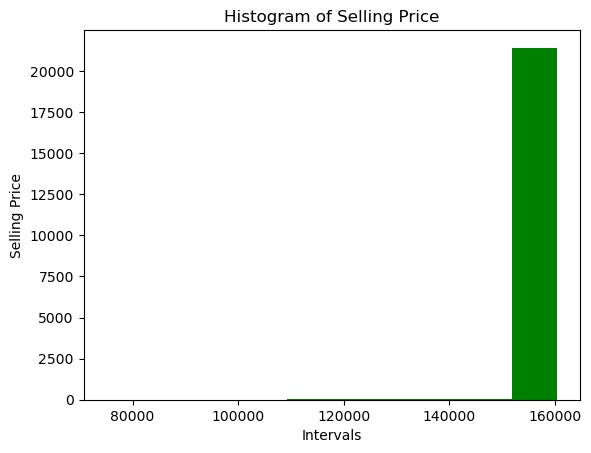

In [21]:
plt.hist(Raw_Housing_Data['Sale Price'], bins = 10, color = 'green')
plt.xlabel('Intervals')
plt.ylabel('Selling Price')
plt.title('Histogram of Selling Price')
plt.show()

In [3]:
import pandas as pd
Raw_Housing_Data = pd.read_csv('Raw_Housing_Prices2.csv')

In [4]:
len(Raw_Housing_Data['Latitude'].unique())

5033

In [5]:
Raw_Housing_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21609 entries, 0 to 21608
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21609 non-null  int64  
 1   Date House was Sold                        21609 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21609 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21609 non-null  float64
 6   Lot Area (in Sqft)                         21609 non-null  float64
 7   No of Floors                               21609 non-null  float64
 8   Waterfront View                            21609 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [7]:
Raw_Housing_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21609 entries, 0 to 21608
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21609 non-null  int64  
 1   Date House was Sold                        21609 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21609 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21609 non-null  float64
 6   Lot Area (in Sqft)                         21609 non-null  float64
 7   No of Floors                               21609 non-null  float64
 8   Waterfront View                            21609 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [9]:
numerical_columns=['No of Bathrooms','Flat Area (in Sqft)','Lot Area (in Sqft)',
                   'Area of the House from Basement (in Sqft)','Latitude',
                  'Longitude','Living Area after Renovation (in Sqft)']

In [14]:
import numpy as np
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy = 'median')
Raw_Housing_Data[numerical_columns] = imputer.fit_transform(Raw_Housing_Data[numerical_columns]) 

In [15]:
Raw_Housing_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21609 entries, 0 to 21608
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21609 non-null  int64  
 1   Date House was Sold                        21609 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21609 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21609 non-null  float64
 6   Lot Area (in Sqft)                         21609 non-null  float64
 7   No of Floors                               21609 non-null  float64
 8   Waterfront View                            21609 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [18]:
imputer = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
Raw_Housing_Data['Zipcode'] = imputer.fit_transform(Raw_Housing_Data['Zipcode'])

ValueError: Expected 2D array, got 1D array instead:
array=[98178. 98125. 98028. ... 98144. 98027. 98144.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [19]:
Raw_Housing_Data['Zipcode'].shape

(21609,)

In [20]:
column = Raw_Housing_Data['Zipcode'].values.reshape(-1,1)
column.shape

(21609, 1)

In [21]:
column = Raw_Housing_Data['Zipcode'].values.reshape(-1,1)
imputer = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
Raw_Housing_Data['Zipcode'] = imputer.fit_transform(column)

In [22]:
Raw_Housing_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21609 entries, 0 to 21608
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21609 non-null  int64  
 1   Date House was Sold                        21609 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21609 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21609 non-null  float64
 6   Lot Area (in Sqft)                         21609 non-null  float64
 7   No of Floors                               21609 non-null  float64
 8   Waterfront View                            21609 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [24]:
Raw_Housing_Data['Zipcode'] = Raw_Housing_Data['Zipcode'].astype(object)
Raw_Housing_Data.dtypes

ID                                             int64
Date House was Sold                           object
Sale Price                                   float64
No of Bedrooms                                 int64
No of Bathrooms                              float64
Flat Area (in Sqft)                          float64
Lot Area (in Sqft)                           float64
No of Floors                                 float64
Waterfront View                               object
No of Times Visited                           object
Condition of the House                        object
Overall Grade                                  int64
Area of the House from Basement (in Sqft)    float64
Basement Area (in Sqft)                        int64
Age of House (in Years)                        int64
Renovated Year                                 int64
Zipcode                                       object
Latitude                                     float64
Longitude                                    f

In [26]:
Raw_Housing_Data['No of Times Visited'].unique()

array([nan, 'Thrice', 'Four', 'Twice', 'Once'], dtype=object)

In [30]:
Raw_Housing_Data

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21604,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21605,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21606,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21607,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [31]:
Raw_Housing_Data['No of Times Visited'].unique()

array([nan, 'Thrice', 'Four', 'Twice', 'Once'], dtype=object)

In [38]:

mapping = {'nan' : '0',
          'Once' : '1',
          'Twice' : '2',
          'Thrice' : '3',
          'Four' : '4'}
Raw_Housing_Data['No of Times Visited']=Raw_Housing_Data['No of Times Visited'].map(mapping)


In [39]:
Raw_Housing_Data['No of Times Visited'].unique()

array([nan, '3', '4', '2', '1'], dtype=object)

In [42]:
import numpy as np
Raw_Housing_Data['Ever Renovate'] = np.where(Raw_Housing_Data['Renovated Year']==0, 'N0', 'Yes')

In [43]:
Raw_Housing_Data.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Ever Renovate
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,N0
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,Yes
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,N0
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000,N0
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503,N0


In [44]:
Raw_Housing_Data['Purchase Year'] = pd.DatetimeIndex(Raw_Housing_Data['Date House was Sold']).year

In [46]:
Raw_Housing_Data['Years since Renovated'] = np.where(Raw_Housing_Data['Ever Renovate'] == 'Yes',
                                                    abs(Raw_Housing_Data['Purchase Year'] - 
                                                       Raw_Housing_Data['Renovated Year']), 0)

In [47]:
Raw_Housing_Data.head()


,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Ever Renovate,Purchase Year,Years since Renovated
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,63,0,98178.0,47.5112,-122.257,1340.0,5650,N0,2017,0
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,67,1991,98125.0,47.7210,-122.319,1690.0,7639,Yes,2017,26
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,85,0,98028.0,47.7379,-122.233,2720.0,8062,N0,2016,0
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,53,0,98136.0,47.5208,-122.393,1360.0,5000,N0,2017,0
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,31,0,98074.0,47.6168,-122.045,1800.0,7503,N0,2016,0


In [48]:
Raw_Housing_Data.drop( columns = ['Purchase Year','Date House was Sold','Renovated Year'],inplace = True)

In [49]:
Raw_Housing_Data.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,...,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Ever Renovate,Years since Renovated
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,...,1180.0,0,63,98178.0,47.5112,-122.257,1340.0,5650,N0,0
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,...,2170.0,400,67,98125.0,47.7210,-122.319,1690.0,7639,Yes,26
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,...,770.0,0,85,98028.0,47.7379,-122.233,2720.0,8062,N0,0
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,...,1050.0,910,53,98136.0,47.5208,-122.393,1360.0,5000,N0,0
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,...,1680.0,0,31,98074.0,47.6168,-122.045,1800.0,7503,N0,0


In [1]:
import pandas as pd
Transformed_Housing_Data=pd.read_csv("Transformed_Housing_Data.csv")

In [2]:
Transformed_Housing_Data['Sale Price'].corr(Transformed_Housing_Data['Flat Area (in Sqft)'])

0.6951704258420669

In [3]:
import numpy as np
np.corrcoef(Transformed_Housing_Data['Sale Price'],Transformed_Housing_Data['Flat Area (in Sqft)'])

array([[1.        , 0.69517043],
       [0.69517043, 1.        ]])

In [6]:
Transformed_Housing_Data.drop(columns = ['ID']).corr(numeric_only=True)

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Years Since Renovation
Sale Price,1.000000,0.339407,0.535124,0.695170,0.101319,0.298913,0.356114,0.680914,0.606527,0.307513,-0.064306,-0.043047,0.402430,0.045401,0.629944,0.092325,0.065907
No of Bedrooms,0.339407,1.000000,0.515813,0.576628,0.031692,0.175536,0.079575,0.349223,0.477549,0.303294,-0.154113,-0.152760,-0.008708,0.129569,0.391771,0.029264,-0.007198
No of Bathrooms,0.535124,0.515813,1.000000,0.754568,0.087732,0.500776,0.187791,0.635638,0.685088,0.283798,-0.505954,-0.203951,0.024570,0.223171,0.568568,0.087226,0.003551
Flat Area (in Sqft),0.695170,0.576628,0.754568,1.000000,0.172721,0.354142,0.284678,0.705725,0.876226,0.435142,-0.318146,-0.199380,0.052538,0.240091,0.756185,0.183223,0.023503
Lot Area (in Sqft),0.101319,0.031692,0.087732,0.172721,1.000000,-0.005162,0.074668,0.102314,0.183492,0.015252,-0.053119,-0.129551,-0.085719,0.229449,0.144507,0.718527,0.013835
No of Floors,0.298913,0.175536,0.500776,0.354142,-0.005162,1.000000,0.029504,0.461368,0.524031,-0.245572,-0.489244,-0.059222,0.049692,0.125620,0.280106,-0.011204,-0.000901
No of Times Visited,0.356114,0.079575,0.187791,0.284678,0.074668,0.029504,1.000000,0.223661,0.167812,0.276974,0.053395,0.084830,0.006162,-0.078453,0.280452,0.072561,0.093546
Overall Grade,0.680914,0.349223,0.635638,0.705725,0.102314,0.461368,0.223661,1.000000,0.705153,0.145232,-0.456711,-0.185844,0.111226,0.201736,0.681362,0.107581,-0.024388
Area of the House from Basement (in Sqft),0.606527,0.477549,0.685088,0.876226,0.183492,0.524031,0.167812,0.705153,1.000000,-0.051825,-0.423848,-0.261124,-0.000819,0.343793,0.731996,0.194106,0.010491
Basement Area (in Sqft),0.307513,0.303294,0.283798,0.435142,0.015252,-0.245572,0.276974,0.145232,-0.051825,1.000000,0.133072,0.074933,0.110451,-0.144822,0.200302,0.017263,0.029158


In [8]:
import pandas as  ps 
import numpy as np 
import matplotlib.pyplot as plt
Transformed_Housing_Data=pd.read_csv("Transformed_Housing_Data.csv")
Transformed_Housing_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21609 entries, 0 to 21608
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21609 non-null  int64  
 1   Sale Price                                 21609 non-null  float64
 2   No of Bedrooms                             21609 non-null  int64  
 3   No of Bathrooms                            21609 non-null  float64
 4   Flat Area (in Sqft)                        21609 non-null  float64
 5   Lot Area (in Sqft)                         21609 non-null  float64
 6   No of Floors                               21609 non-null  float64
 7   Waterfront View                            21609 non-null  object 
 8   No of Times Visited                        21609 non-null  int64  
 9   Condition of the House                     21609 non-null  object 
 10  Overall Grade         

In [9]:
Transformed_Housing_Data.drop( columns = 'ID', inplace = True)

In [10]:
Transformed_Housing_Data['Condition of the House'].head(10)

0         Fair
1         Fair
2         Fair
3    Excellent
4         Fair
5         Fair
6         Fair
7         Fair
8         Fair
9         Fair
Name: Condition of the House, dtype: object

In [11]:
Transformed_Housing_Data['Condition of the House'].value_counts()

Condition of the House
Fair         14028
Good          5678
Excellent     1701
Okay           172
Bad             30
Name: count, dtype: int64

<Axes: xlabel='Condition of the House'>

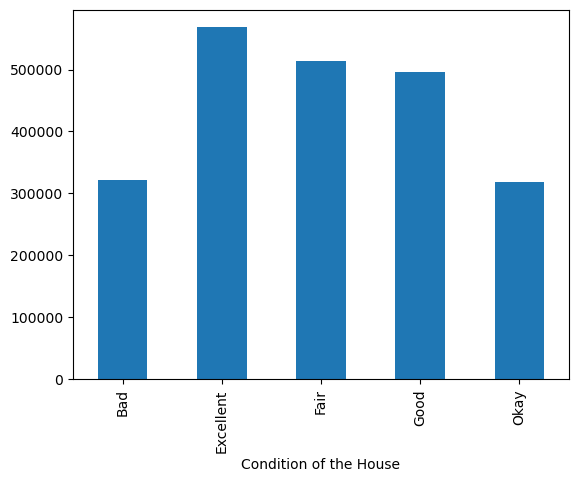

In [12]:
Transformed_Housing_Data.groupby('Condition of the House',
                                )['Sale Price'].mean().plot(kind='bar')

<Axes: xlabel='Condition of the House'>

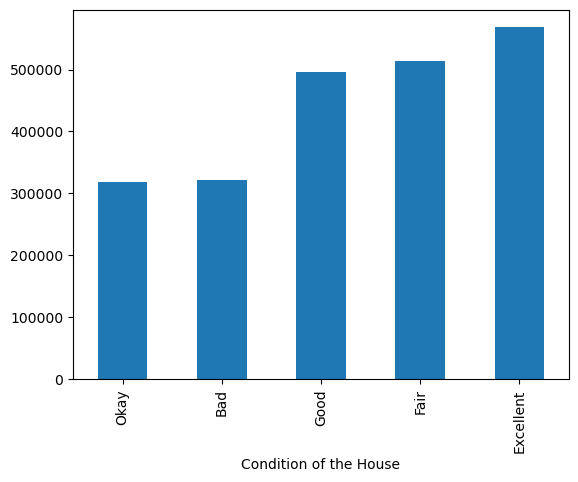

In [13]:
Transformed_Housing_Data.groupby('Condition of the House',
                                )['Sale Price'].mean().sort_values().plot(kind = 'bar')

<Axes: xlabel='Waterfront View'>

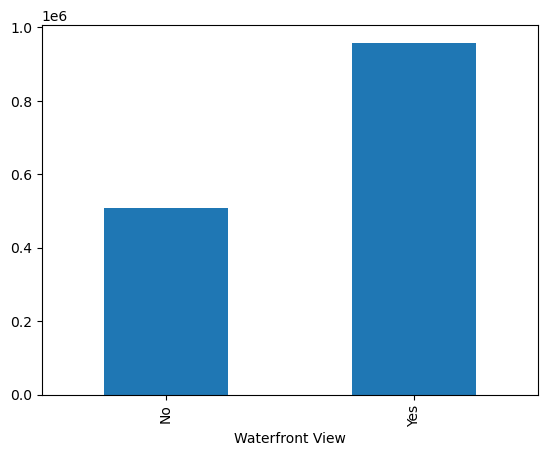

In [14]:
Transformed_Housing_Data.groupby('Waterfront View',
                                )['Sale Price'].mean().sort_values().plot(kind = 'bar')

<Axes: xlabel='Ever Renovated'>

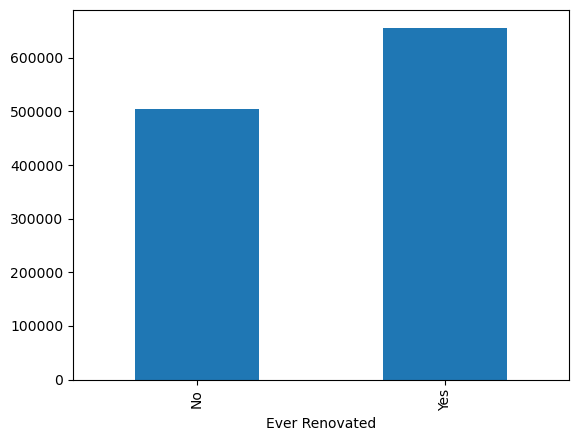

In [15]:
Transformed_Housing_Data.groupby('Ever Renovated',
                                )['Sale Price'].mean().sort_values().plot(kind = 'bar')

<Axes: xlabel='Zipcode'>

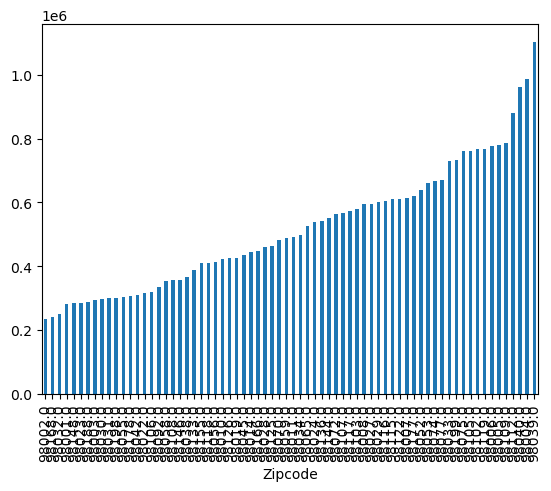

In [16]:
Transformed_Housing_Data.groupby('Zipcode',
                                )['Sale Price'].mean().sort_values().plot(kind = 'bar')

In [18]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [19]:
Transformed_Housing_Data = Transformed_Housing_Data.rename(columns = {'Sale Price' : 'Sale_Price'})

In [20]:
Transformed_Housing_Data = Transformed_Housing_Data.rename(columns = {'Condition of the House' : 'Condition_of_the_House'})

In [21]:
Transformed_Housing_Data = Transformed_Housing_Data.rename(columns = {'Ever Renovated' : 'Ever_Renovated'})

In [30]:
Transformed_Housing_Data = Transformed_Housing_Data.rename(columns = {'Waterfront View' : 'Waterfront_View'})

In [31]:
Transformed_Housing_Data.head()

,Sale_Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront_View,No of Times Visited,Condition_of_the_House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Ever_Renovated,Years Since Renovation
0,221900.0,3,1.00,1180.0,5650.0,1.0,No,0,Fair,7,1180.0,0,63,98178.0,47.5112,-122.257,1340.0,5650,No,0
1,538000.0,3,2.25,2570.0,7242.0,2.0,No,0,Fair,7,2170.0,400,67,98125.0,47.7210,-122.319,1690.0,7639,Yes,26
2,180000.0,2,1.00,770.0,10000.0,1.0,No,0,Fair,6,770.0,0,85,98028.0,47.7379,-122.233,2720.0,8062,No,0
3,604000.0,4,3.00,1960.0,5000.0,1.0,No,0,Excellent,7,1050.0,910,53,98136.0,47.5208,-122.393,1360.0,5000,No,0
4,510000.0,3,2.00,1680.0,8080.0,1.0,No,0,Fair,8,1680.0,0,31,98074.0,47.6168,-122.045,1800.0,7503,No,0


In [32]:
Transformed_Housing_Data['Waterfront_View'].unique()

array(['No', 'Yes'], dtype=object)

In [34]:
mod = ols('Sale_Price ~ Condition_of_the_House',data = Transformed_Housing_Data).fit()

In [35]:
Anova_Table = sm.stats.anova_lm(mod, typ = 2)

In [36]:
print(Anova_Table)

                              sum_sq       df         F        PR(>F)
Condition_of_the_House  1.441831e+13      4.0  58.25563  5.447605e-49
Residual                1.336752e+15  21604.0       NaN           NaN


In [37]:
mod = ols('Sale_Price ~ Waterfront_View',data = Transformed_Housing_Data).fit()
sm.stats.anova_lm(mod, typ = 2)

,sum_sq,df,F,PR(>F)
Waterfront_View,3.283737e+13,1.0,538.192683,1.275558e-117
Residual,1.318333e+15,21607.0,NaN,NaN


In [38]:
mod = ols('Sale_Price ~ Ever_Renovated',data = Transformed_Housing_Data).fit()
sm.stats.anova_lm(mod, typ = 2)

,sum_sq,df,F,PR(>F)
Ever_Renovated,1.998463e+13,1.0,324.378469,5.419055e-72
Residual,1.331185e+15,21607.0,NaN,NaN


In [39]:
mod = ols('Sale_Price ~ Zipcode',data = Transformed_Housing_Data).fit()
sm.stats.anova_lm(mod, typ = 2)

,sum_sq,df,F,PR(>F)
Zipcode,2.503765e+12,1.0,40.112844,2.444308e-10
Residual,1.348666e+15,21607.0,NaN,NaN


In [4]:
import pandas as  ps 
import numpy as np 
import matplotlib.pyplot as plt
Transformed_Housing_Data=pd.read_csv("Transformed_Housing_Data.csv")


In [5]:
Transformed_Housing_Data = Transformed_Housing_Data.rename(columns = {'Condition of the House' : 'Condition_of_the_House'})

In [6]:
Transformed_Housing_Data = pd.get_dummies(Transformed_Housing_Data,
                                         columns = ['Condition_of_the_House'],
                                         drop_first = True)

In [7]:
Transformed_Housing_Data.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Overall Grade,...,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Ever Renovated,Years Since Renovation,Condition_of_the_House_Excellent,Condition_of_the_House_Fair,Condition_of_the_House_Good,Condition_of_the_House_Okay
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,No,0,7,...,47.5112,-122.257,1340.0,5650,No,0,False,True,False,False
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,No,0,7,...,47.7210,-122.319,1690.0,7639,Yes,26,False,True,False,False
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,No,0,6,...,47.7379,-122.233,2720.0,8062,No,0,False,True,False,False
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,No,0,7,...,47.5208,-122.393,1360.0,5000,No,0,True,False,False,False
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,No,0,8,...,47.6168,-122.045,1800.0,7503,No,0,False,True,False,False


In [8]:
Transformed_Housing_Data = Transformed_Housing_Data.rename(columns = {'Ever Renovated' : 'Ever_Renovated'})
Transformed_Housing_Data = Transformed_Housing_Data.rename(columns = {'Waterfront View' : 'Waterfront_View'})

In [9]:
Transformed_Housing_Data = pd.get_dummies(Transformed_Housing_Data,
                                         columns = ['Ever_Renovated'],
                                         drop_first = True)
Transformed_Housing_Data = pd.get_dummies(Transformed_Housing_Data,
                                         columns = ['Waterfront_View'],
                                         drop_first = True)

In [10]:
Transformed_Housing_Data.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),...,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Years Since Renovation,Condition_of_the_House_Excellent,Condition_of_the_House_Fair,Condition_of_the_House_Good,Condition_of_the_House_Okay,Ever_Renovated_Yes,Waterfront_View_Yes
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,0,7,1180.0,...,-122.257,1340.0,5650,0,False,True,False,False,False,False
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,0,7,2170.0,...,-122.319,1690.0,7639,26,False,True,False,False,True,False
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,0,6,770.0,...,-122.233,2720.0,8062,0,False,True,False,False,False,False
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,0,7,1050.0,...,-122.393,1360.0,5000,0,True,False,False,False,False,False
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,0,8,1680.0,...,-122.045,1800.0,7503,0,False,True,False,False,False,False


In [12]:
Transformed_Housing_Data = Transformed_Housing_Data.rename(columns = {'Sale Price' : 'Sale_Price'})

In [14]:
Zip_Table = Transformed_Housing_Data.groupby('Zipcode').agg({'Sale_Price' : 'mean'}).sort_values('Sale_Price', ascending = True)

In [15]:
Zip_Table.head()

,Sale_Price
Zipcode,
98002.0,234284.035176
98168.0,240328.371747
98032.0,251296.240000
98001.0,280804.690608
98148.0,284908.596491


In [16]:
Zip_Table['Zipcode_Group'] = pd.cut(Zip_Table['Sale_Price'], bins = 10,
                                   labels = ['Zipcode_Group_0',
                                            'Zipcode_Group-_1',
                                            'Zipcode_Group-_2',
                                            'Zipcode_Group-_3',
                                            'Zipcode_Group-_4',
                                            'Zipcode_Group-_5',
                                            'Zipcode_Group-_6',
                                            'Zipcode_Group-_7',
                                            'Zipcode_Group-_8',
                                            'Zipcode_Group-_9'],
                                   include_lowest = True)

In [17]:
Zip_Table = Zip_Table.drop(columns = 'Sale_Price')

In [18]:
Transformed_Housing_Data = pd.merge(Transformed_Housing_Data,
                                    Zip_Table,
                                    left_on = 'Zipcode',
                                    how = 'left',
                                    right_index = True)

In [19]:
Transformed_Housing_Data = Transformed_Housing_Data.drop( columns = 'Zipcode')

In [20]:
Transformed_Housing_Data.head()

,ID,Sale_Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),...,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Years Since Renovation,Condition_of_the_House_Excellent,Condition_of_the_House_Fair,Condition_of_the_House_Good,Condition_of_the_House_Okay,Ever_Renovated_Yes,Waterfront_View_Yes,Zipcode_Group
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,0,7,1180.0,...,1340.0,5650,0,False,True,False,False,False,False,Zipcode_Group_0
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,0,7,2170.0,...,1690.0,7639,26,False,True,False,False,True,False,Zipcode_Group-_2
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,0,6,770.0,...,2720.0,8062,0,False,True,False,False,False,False,Zipcode_Group-_2
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,0,7,1050.0,...,1360.0,5000,0,True,False,False,False,False,False,Zipcode_Group-_3
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,0,8,1680.0,...,1800.0,7503,0,False,True,False,False,False,False,Zipcode_Group-_4


In [21]:
Transformed_Housing_Data = pd.get_dummies(Transformed_Housing_Data,
                                         columns = ['Zipcode_Group'],
                                         drop_first = True)

In [22]:
Transformed_Housing_Data.head()

,ID,Sale_Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),...,Waterfront_View_Yes,Zipcode_Group_Zipcode_Group-_1,Zipcode_Group_Zipcode_Group-_2,Zipcode_Group_Zipcode_Group-_3,Zipcode_Group_Zipcode_Group-_4,Zipcode_Group_Zipcode_Group-_5,Zipcode_Group_Zipcode_Group-_6,Zipcode_Group_Zipcode_Group-_7,Zipcode_Group_Zipcode_Group-_8,Zipcode_Group_Zipcode_Group-_9
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,0,7,1180.0,...,False,False,False,False,False,False,False,False,False,False
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,0,7,2170.0,...,False,False,True,False,False,False,False,False,False,False
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,0,6,770.0,...,False,False,True,False,False,False,False,False,False,False
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,0,7,1050.0,...,False,False,False,True,False,False,False,False,False,False
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,0,8,1680.0,...,False,False,False,False,True,False,False,False,False,False


In [7]:
import pandas as  pd 
import numpy as np 
import matplotlib.pyplot as plt
Transformed_Housing_Data_2=pd.read_csv("Transformed_Housing_Data2.csv")

In [8]:
Y = Transformed_Housing_Data_2.iloc[:,0]
X = Transformed_Housing_Data_2.iloc[:,1:31]

In [9]:
X.head()

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),...,Waterfront_View_Yes,Zipcode_Group_Zipcode_Group_1,Zipcode_Group_Zipcode_Group_2,Zipcode_Group_Zipcode_Group_3,Zipcode_Group_Zipcode_Group_4,Zipcode_Group_Zipcode_Group_5,Zipcode_Group_Zipcode_Group_6,Zipcode_Group_Zipcode_Group_7,Zipcode_Group_Zipcode_Group_8,Zipcode_Group_Zipcode_Group_9
0,3,1.00,1180.0,5650.0,1.0,0,7,1180.0,0,63,...,0,0,0,0,0,0,0,0,0,0
1,3,2.25,2570.0,7242.0,2.0,0,7,2170.0,400,67,...,0,0,1,0,0,0,0,0,0,0
2,2,1.00,770.0,10000.0,1.0,0,6,770.0,0,85,...,0,0,1,0,0,0,0,0,0,0
3,4,3.00,1960.0,5000.0,1.0,0,7,1050.0,910,53,...,0,0,0,1,0,0,0,0,0,0
4,3,2.00,1680.0,8080.0,1.0,0,8,1680.0,0,31,...,0,0,0,0,1,0,0,0,0,0


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3)

In [13]:
X_train.shape

(15126, 30)

In [14]:
X_test.shape

(6483, 30)

In [15]:
Y_train.shape

(15126,)

In [16]:
Y_test.shape

(6483,)

In [3]:
import pandas as  pd 
import numpy as np 
import matplotlib.pyplot as plt
Transformed_Housing_Data_2=pd.read_csv("Transformed_Housing_Data2.csv")

In [4]:
Y = Transformed_Housing_Data_2.iloc[:,0]
X = Transformed_Housing_Data_2.iloc[:,1:31]

In [5]:
X.describe()

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),...,Waterfront_View_Yes,Zipcode_Group_Zipcode_Group_1,Zipcode_Group_Zipcode_Group_2,Zipcode_Group_Zipcode_Group_3,Zipcode_Group_Zipcode_Group_4,Zipcode_Group_Zipcode_Group_5,Zipcode_Group_Zipcode_Group_6,Zipcode_Group_Zipcode_Group_7,Zipcode_Group_Zipcode_Group_8,Zipcode_Group_Zipcode_Group_9
count,21609.000000,21609.000000,21609.000000,2.160900e+04,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,...,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000
mean,3.370771,2.114709,2079.872553,1.510641e+04,1.494215,0.234347,7.623490,1788.319589,291.513490,46.999722,...,0.007543,0.109399,0.188625,0.149706,0.186681,0.043824,0.076450,0.012449,0.027720,0.002314
std,0.929916,0.770097,918.347816,4.142353e+04,0.539909,0.766382,1.105519,827.977604,442.570991,29.373317,...,0.086525,0.312146,0.391220,0.356791,0.389665,0.204709,0.265722,0.110879,0.164173,0.048048
min,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,1.000000,290.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,7.000000,1190.000000,0.000000,21.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,2.250000,1910.000000,7.619000e+03,1.500000,0.000000,7.000000,1560.000000,0.000000,43.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,2.500000,2550.000000,1.068700e+04,2.000000,0.000000,8.000000,2210.000000,560.000000,67.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,4.000000,10.000000,9410.000000,4820.000000,118.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
from sklearn import preprocessing

In [9]:
scale = preprocessing.StandardScaler()

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3)

In [13]:
X_train = scale.fit_transform(X_train)

In [14]:
X_train

array([[ 0.68862578, -0.15559327,  0.1687964 , ..., -0.11487294,
         5.85309672, -0.04815873],
       [-1.50240358, -0.15559327, -0.41621608, ..., -0.11487294,
        -0.17084973, -0.04815873],
       [ 0.68862578,  0.16809038,  1.46882415, ..., -0.11487294,
        -0.17084973, -0.04815873],
       ...,
       [-0.4068889 ,  1.78650865,  0.0171265 , ..., -0.11487294,
        -0.17084973, -0.04815873],
       [ 1.78414046,  1.13914134,  1.06798226, ..., -0.11487294,
        -0.17084973, -0.04815873],
       [ 0.68862578, -0.15559327,  0.17962997, ..., -0.11487294,
        -0.17084973, -0.04815873]])

In [15]:
X_test = scale.fit_transform(X_test)

In [16]:
X_test

array([[-1.41369739, -1.44125933, -1.32265322, ..., -0.10597498,
        -0.16409924, -0.04815713],
       [-0.38125398,  0.52060046, -0.70531022, ..., -0.10597498,
        -0.16409924, -0.04815713],
       [ 0.65118943, -0.46032943, -0.18718307, ..., -0.10597498,
        -0.16409924, -0.04815713],
       ...,
       [-0.38125398, -0.46032943,  0.06636852, ..., -0.10597498,
        -0.16409924, -0.04815713],
       [ 0.65118943, -1.44125933, -0.40766271, ..., -0.10597498,
        -0.16409924, -0.04815713],
       [-0.38125398, -1.44125933, -1.03602968, ..., -0.10597498,
        -0.16409924, -0.04815713]])